**Predicción de precio de un carro**
    
Objetivo del negocio: Estimar el precio de un vehículo basado en sus características.


* Variable objetivo: Price
* ¿Es un problema de clasificación o regresión?
  Es un problema de regresion
* ¿Por qué?
  Porque la variable objetivo (price) es numérica continua. El modelo debe estimar el precio de un automóvil a partir de sus características, como el tamaño del motor, la potencia, el peso, el tipo de combustible y otras variables.
* Descripcion del problema
El datoset contiene información técnica y comercial de diferentes automóviles, que incluye características como el tamaño del motor, la potencia, el peso, el tipo de combustible, la marca y otras especificaciones. El objetivo es construir un modelo de aprendizaje automático capaz de predecir el precio de un vehículo a partir de estas características. Este tipo de modelos puede ser útil para concesionarios, aseguradoras o plataformas de compra y venta de vehículos al estimar el valor de mercado de un automóvil.

In [1]:
#Importar librerias
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt


In [2]:
import kagglehub
import pandas as pd
import os

# Cargar el dataset desde KaggleHub
path = kagglehub.dataset_download("hellbuoy/car-price-prediction")

# Ver los archivos que contiene
print(os.listdir(path))

# Cargar el archivo CSV
carros = pd.read_csv(os.path.join(path, "CarPrice_Assignment.csv"))

# Crear una copia del DataFrame
carros1 = carros.copy()

# Verificar que cargó correctamente
carros1.head()


100%|██████████| 18.1k/18.1k [00:00<00:00, 19.0MB/s]

Extracting files...
['Data Dictionary - carprices.xlsx', 'CarPrice_Assignment.csv']


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


Exploracion de datos


In [3]:
#generar copia para trabajar en ella
carros1=carros.copy()

In [4]:
carros1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [5]:
carros1.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [6]:
#verificar valores nulos
carros1.isnull().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


In [7]:
#valores duplicados
carros1.duplicated().sum()

np.int64(0)

In [8]:
#variables numericas
carros1.select_dtypes(include=['int64','float64']).columns

Index(['car_ID', 'symboling', 'wheelbase', 'carlength', 'carwidth',
       'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [9]:
#variable categorica
carros1.select_dtypes(include=['object']).columns

Index(['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody',
       'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber',
       'fuelsystem'],
      dtype='object')

In [10]:
carros1["CarName"].unique()

array(['alfa-romero giulia', 'alfa-romero stelvio',
       'alfa-romero Quadrifoglio', 'audi 100 ls', 'audi 100ls',
       'audi fox', 'audi 5000', 'audi 4000', 'audi 5000s (diesel)',
       'bmw 320i', 'bmw x1', 'bmw x3', 'bmw z4', 'bmw x4', 'bmw x5',
       'chevrolet impala', 'chevrolet monte carlo', 'chevrolet vega 2300',
       'dodge rampage', 'dodge challenger se', 'dodge d200',
       'dodge monaco (sw)', 'dodge colt hardtop', 'dodge colt (sw)',
       'dodge coronet custom', 'dodge dart custom',
       'dodge coronet custom (sw)', 'honda civic', 'honda civic cvcc',
       'honda accord cvcc', 'honda accord lx', 'honda civic 1500 gl',
       'honda accord', 'honda civic 1300', 'honda prelude',
       'honda civic (auto)', 'isuzu MU-X', 'isuzu D-Max ',
       'isuzu D-Max V-Cross', 'jaguar xj', 'jaguar xf', 'jaguar xk',
       'maxda rx3', 'maxda glc deluxe', 'mazda rx2 coupe', 'mazda rx-4',
       'mazda glc deluxe', 'mazda 626', 'mazda glc', 'mazda rx-7 gs',
       'mazda glc 

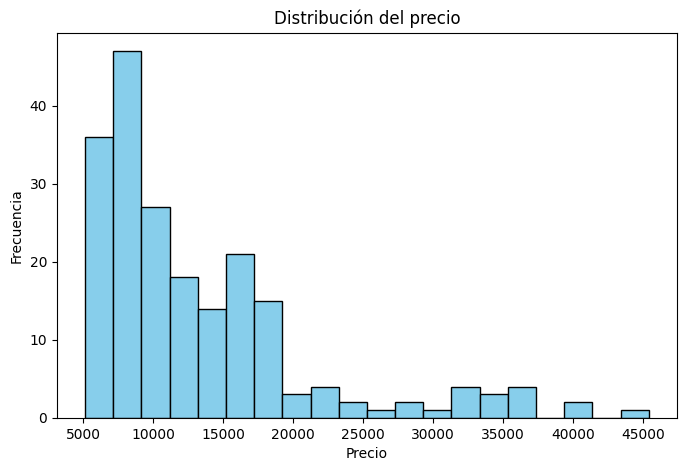

In [11]:
#Distribucion de precio

import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))
plt.hist(carros1["price"],
         bins=20,
         color="skyblue",
         edgecolor="black")
plt.title("Distribución del precio")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()


Se puede observar que existe un volumen reducido de carros con un valor mas alto,mientras que los carros con valor bahjo y medio comprende un gran porcentaje

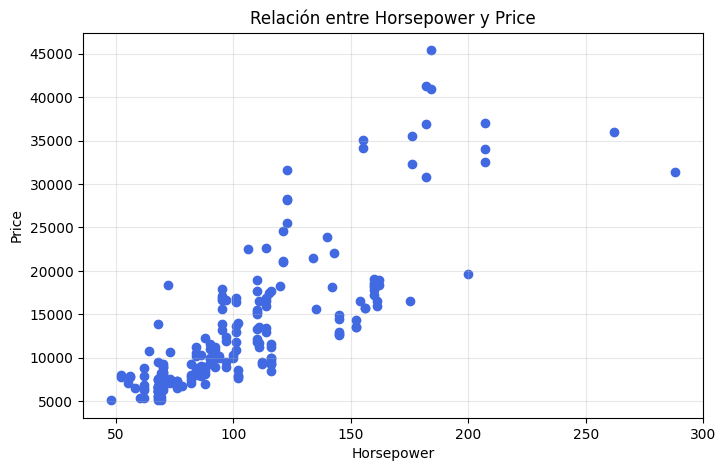

In [12]:
plt.figure(figsize=(8,5))
plt.scatter(carros1["horsepower"], carros1["price"], color="royalblue")
plt.title("Relación entre Horsepower y Price")
plt.xlabel("Horsepower")
plt.ylabel("Price")
plt.grid(alpha=0.3)
plt.show()

Se evidencia que cuando la variable 'Horsepower' aumenta, la variable 'Price' aumenta de manera proporcional, esto indica que es una variable importante para la adquisicion de un automovil

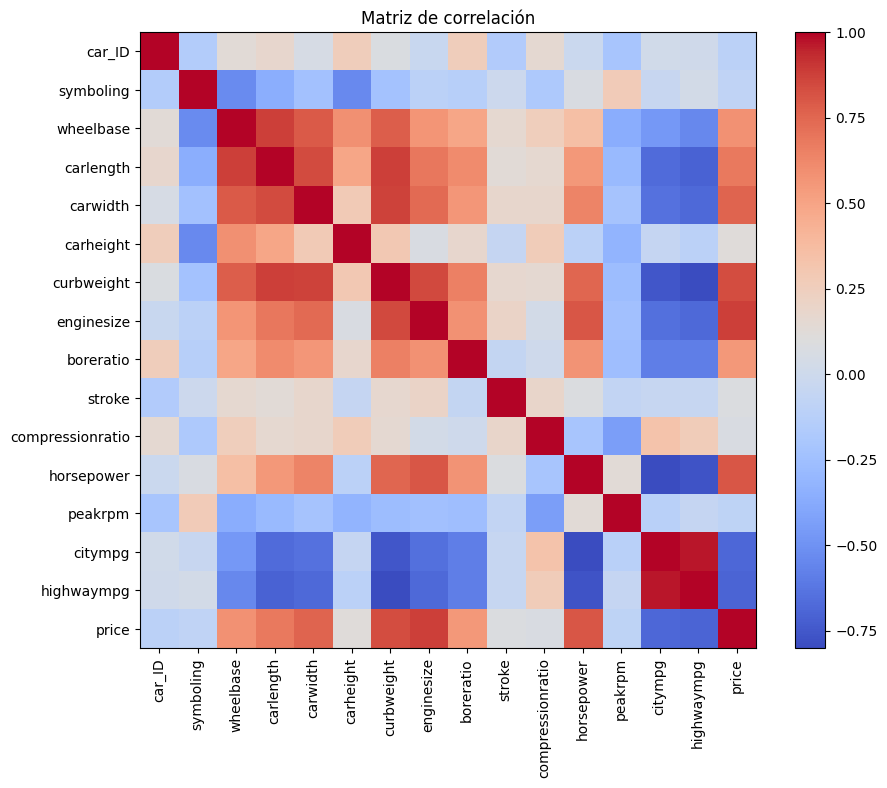

In [13]:
#Correlacion precio_caracteristicas
corr = carros1.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matriz de correlación")
plt.show()

La matriz de correlación muestra la relación entre las variables numéricas del conjunto de datos. Se observa que enginesize, horsepower y curbweight presentan una fuerte correlación positiva con el precio del vehículo, lo que indica que estas variables tienen una influencia importante en la predicción del precio

3. Preparacion de Datos

In [14]:
carros1.columns.tolist()

['car_ID',
 'symboling',
 'CarName',
 'fueltype',
 'aspiration',
 'doornumber',
 'carbody',
 'drivewheel',
 'enginelocation',
 'wheelbase',
 'carlength',
 'carwidth',
 'carheight',
 'curbweight',
 'enginetype',
 'cylindernumber',
 'enginesize',
 'fuelsystem',
 'boreratio',
 'stroke',
 'compressionratio',
 'horsepower',
 'peakrpm',
 'citympg',
 'highwaympg',
 'price']

In [15]:
carros1.select_dtypes(include="object").columns

Index(['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody',
       'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber',
       'fuelsystem'],
      dtype='object')

In [16]:
carros1 = pd.get_dummies(carros1, drop_first=True)

In [17]:
carros1 = carros1.drop("car_ID", axis=1)

In [18]:
#Seprarar x e y
X = carros1.drop("price", axis=1)
y = carros1["price"]

In [19]:
#Dividir
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

4. Modelado
5. Evaluacion

In [20]:
print(X_train.dtypes.value_counts())

bool       175
int64        7
float64      7
Name: count, dtype: int64


In [25]:
#Modelo 1
from sklearn.linear_model import LinearRegression

modelo1 = LinearRegression()

modelo1.fit(X_train, y_train)

pred1 = modelo1.predict(X_test)

In [26]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [27]:
mae = mean_absolute_error(y_test, pred1)
mse = mean_squared_error(y_test, pred1)
r2 = r2_score(y_test, pred1)

print("MAE:", mae)
print("MSE:", mse)
print("R²:", r2)

MAE: 4177.295631354042
MSE: 41547027.85288088
R²: 0.47371533157380974


In [28]:
#Predicciones
comparacion = pd.DataFrame({
    "Precio Real": y_test,
    "Precio Predicho": pred1
})

comparacion.head(10)

,Precio Real,Precio Predicho
15,30760.000,13907.571516
9,17859.167,20592.932928
100,9549.000,13012.625177
132,11850.000,7686.264150
68,28248.000,27128.654184
95,7799.000,6820.117720
159,7788.000,8821.019914
162,9258.000,9198.090239
147,10198.000,15336.599012
182,7775.000,12531.695578


In [29]:
#Segundo Modelo
from sklearn.tree import DecisionTreeRegressor
modelo2 = DecisionTreeRegressor(random_state=42)

In [30]:
#Entrenar Modelo
modelo2.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [31]:
#Predicciones
pred2 = modelo2.predict(X_test)

In [32]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [33]:
mae2 = mean_absolute_error(y_test, pred2)
mse2 = mean_squared_error(y_test, pred2)
r22 = r2_score(y_test, pred2)

print("MAE:", mae2)
print("MSE:", mse2)
print("R²:", r22)

MAE: 2200.1422682926827
MSE: 11376015.613509487
R²: 0.855897691975291


In [34]:
comparacion2 = pd.DataFrame({
    "Precio Real": y_test.values,
    "Precio Predicho": pred2
})

comparacion2.head(10)

,Precio Real,Precio Predicho
0,30760.000,36880.0
1,17859.167,18420.0
2,9549.000,8845.0
3,11850.000,11694.0
4,28248.000,36000.0
5,7799.000,5118.0
6,7788.000,6918.0
7,9258.000,8358.0
8,10198.000,8949.0
9,7775.000,7995.0


In [37]:
#Comparacion de Modelos
comparacion_modelos = pd.DataFrame({
    "Modelo": ["Regresión Lineal", "Árbol de Decisión"],
    "MAE": [mae, mae2],
    "MSE": [mse, mse2],
    "R²": [r2, r22]
})

comparacion_modelos

,Modelo,MAE,MSE,R²
0,Regresión Lineal,4177.295631,4.154703e+07,0.473715
1,Árbol de Decisión,2200.142268,1.137602e+07,0.855898


In [39]:
importancia = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo2.feature_importances_
})

importancia = importancia.sort_values(
    by="Importancia",
    ascending=False
)

In [40]:
#Importancia de la variable
importancia.head(10)

,Variable,Importancia
6,enginesize,0.648296
5,curbweight,0.264989
8,stroke,0.015257
3,carwidth,0.013215
10,horsepower,0.011873
34,CarName_buick regal sport coupe (turbo),0.011699
11,peakrpm,0.007924
98,CarName_peugeot 504,0.004049
4,carheight,0.003522
13,highwaympg,0.002597


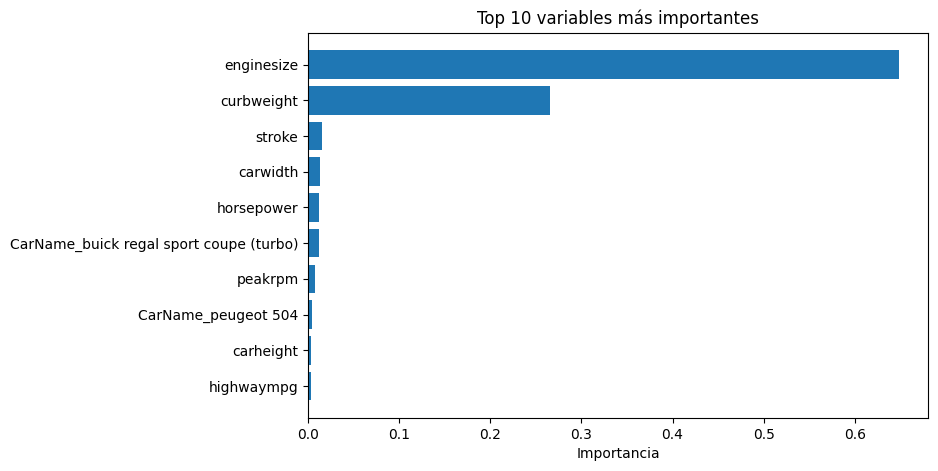

In [41]:
#Grafica de la variable mas importante
plt.figure(figsize=(8,5))

plt.barh(
    importancia["Variable"][:10],
    importancia["Importancia"][:10]
)

plt.title("Top 10 variables más importantes")
plt.xlabel("Importancia")
plt.gca().invert_yaxis()

plt.show()

**6. Preguntas**

¿Qué tan bueno es el modelo?

El modelo de Árbol de Decisión presentó un mejor desempeño al obtener un coeficiente de determinación (R²) de 0.8666, lo que indica que explica aproximadamente el 86.66 % de la variación en el precio de los vehículos. Además, presentó un error absoluto medio (MAE) de 2098.31, mucho mas inferior al obtenido por la Regresión Lineal, demostrando una mayor precisión en las predicciones.

¿Qué variable parece influir más en la predicción?
De acuerdo con la importancia de variables calculada por el modelo de Árbol de Decisión, la variable enginesize (tamaño del motor) fue la que tuvo mayor influencia en la predicción del precio, con una importancia de 0.648. La segunda variable más importante fue curbweight (peso del vehículo), con una importancia de 0.261. Esto indica que el tamaño del motor y el peso del vehículo son factores determinantes para estimar el precio de un automóvi



¿Qué mejorarías si tuvieras más tiempo?

Si dispusiera de más tiempo, se realizaría un proceso adicional de  seleccion, únicamente las variables más relevantes y eliminando aquellas con poca influencia. También se probarían otros algoritmos como Random Forest o Gradient Boosting y se optimizarían los hiperparámetros mediante validación cruzada para mejorar el rendimiento del modelo.





Conclusion Final
El objetivo del taller fue desarrollar un modelo capaz de predecir el precio de los vehículos utilizando técnicas de aprendizaje automático. Tras realizar el análisis exploratorio, la preparación de los datos y el entrenamiento de dos modelos, se concluyó que el Árbol de Decisión obtuvo un rendimiento significativamente superior al de la Regresión Lineal, logrando una mayor precisión en las predicciones y una mejor capacidad para explicar la variación de los precios.

